In [ ]:
!nvidia-smi
!python --version

/bin/bash: line 1: nvidia-smi: command not found
Python 3.11.11


## 1 Prepare environment

### 1.1 Import astronomical packages
+ `lightkurve` - [library](https://lightkurve.github.io/lightkurve/index.html) library for discovery Kepler and Tess datasets
+ `astropy` - [library](https://www.astropy.org/) designed for astronomy and astrophysics. It provides a comprehensive suite of tools for handling astronomical data, performing scientific computations, and supporting research workflows
+ `astroquery` - [library](https://astroquery.readthedocs.io/en/latest/) with a set of tools for querying astronomical web forms and databases.

### 1.2 Import math and visialization libraries
+ `numpy` - [library](https://numpy.org/) support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
+ `pandas` - [library](https://pandas.pydata.org/) for data manipulation and analytics
+ `maptlotlib` - [library](https://matplotlib.org/) for for visualization static, animated, and interactive visualizations
+ `ffmpeg` - [library](https://www.ffmpeg.org/) for handling video, audio and multimedia files and streams (enable animations in lightkurve)
+ `ipympl` - [library](https://matplotlib.org/ipympl/) for enabling interactive Matplotlib plots directly within Jupyter Notebooks

In [ ]:
import io

# astronomy packages
try:
  import lightkurve as lk
except:
  !pip install lightkurve --upgrade
  # ffmpeg animation library
  # !apt-get install -y ffmpeg
  import lightkurve as lk

try:
  import astropy as ast
except:
  !pip install astropy --upgrade
  import astropy as ast

import astroquery as aq

# math packages
import numpy as np
import pandas as pd

# visualization packages
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline
# %matplotlib widget
# %matplotlib notebook
try:
  import ffmpeg
except:
  !apt-get install -y ffmpeg
try:
  import ipympl
except:
  !pip install ipympl

# Check versions
print('Lightkurve version: ' + lk.__version__)
print('Astropy version: ' + ast.__version__)
print('Numpy version: ' + np.__version__)
print('Matplotlib version: ' + matplotlib.__version__)
print('Pandas version: ' + pd.__version__)

## 2 Define interested starts
Definied starts available from TESS Input Catalog (TIC) and append prefix TIC.

In [ ]:
def append_prefix(df: pd.DataFrame,
                  prefix="TIC "):
  # Initialize an empty list
  list = []

  # Iterate through each number in the dataframe
  for num in df[0]:
      list.append(f"{prefix}{num}")

  # Convert to a NumPy array
  return np.array(list)

In [ ]:
star_name = ["TIC 116986071"]
star_names_50_1_url = "https://raw.githubusercontent.com/serhiikartashov/discovery-astronomic-objects/refs/heads/main/data/tess_vstars_50_1.csv"
df = pd.read_csv(star_names_50_1_url, header=None)

# Convert to a NumPy array
star_names_50_1 = append_prefix(df)

# Print the final array
print(star_names_50_1)

['TIC 116986071' 'TIC 1551778142' 'TIC 159332859' 'TIC 187531837'
 'TIC 198183379' 'TIC 219100171' 'TIC 229510866' 'TIC 229704090'
 'TIC 229752721' 'TIC 229937189' 'TIC 230019644' 'TIC 230071306'
 'TIC 230083885' 'TIC 230381054' 'TIC 233745344' 'TIC 237116143'
 'TIC 237201691' 'TIC 237205536' 'TIC 237206223' 'TIC 237213653'
 'TIC 251105281' 'TIC 251333156' 'TIC 252452281' 'TIC 260694891'
 'TIC 263931812' 'TIC 275259749' 'TIC 281482721' 'TIC 288268074'
 'TIC 29221935' 'TIC 315756675' 'TIC 327756689' 'TIC 329351663'
 'TIC 341839700' 'TIC 341871585' 'TIC 351695758' 'TIC 353241568'
 'TIC 353257675' 'TIC 364184518' 'TIC 366873414' 'TIC 376869068'
 'TIC 388565206' 'TIC 392126428' 'TIC 392569693' 'TIC 429059113'
 'TIC 441765151' 'TIC 446041643' 'TIC 467835395' 'TIC 82243350'
 'TIC 85855399' 'TIC 94541786']


## 3 Collect datasets for defined start

In [ ]:
pixelfile = lk.search_targetpixelfile("TIC 116986071", sector=86, mission="TESS").download();
# pixelfile.plot(aperture_mask="pipeline");
lc = pixelfile.to_lightcurve(method="pld").remove_outliers().flatten();
# lc.to_periodogram("bls").plot()
period = lc.to_periodogram("bls").period_at_max_power
lc.fold(period).scatter();

In [ ]:
pixelfile = lk.search_targetpixelfile("TIC 116986071", sector=86, mission="TESS").download();
# pixelfile.plot(aperture_mask="pipeline");
lc = pixelfile.to_lightcurve(method="pld").remove_outliers().flatten();
# lc.to_periodogram("bls").plot()
period = lc.to_periodogram("bls").period_at_max_power
lc.fold(period).scatter();

In [ ]:
from lightkurve import search_targetpixelfile
pixelfile = search_targetpixelfile("TIC 116986071", sector=86, mission="TESS").download();
# lc_collection = search_lightcurve("TIC 116986071", sector=86, mission="TESS").download();

In [ ]:
import ipython

print(f"mlxtend version: {ipython.__version__}")

ModuleNotFoundError: No module named 'ipython'

In [ ]:
%matplotlib notebook
pixelfile.animate();

# plt.show()

<IPython.core.display.Javascript object>

In [ ]:
pixelfile.to_lightcurve(method="pld").scatter();

In [ ]:
lc = pixelfile.to_lightcurve(method="pld").remove_outliers().flatten();
period = lc.to_periodogram("bls").period_at_max_power

In [ ]:
# pixelfile.plot(frame=1);

In [ ]:
# from lightkurve import search_lightcurve

<Figure size 1000x600 with 0 Axes>

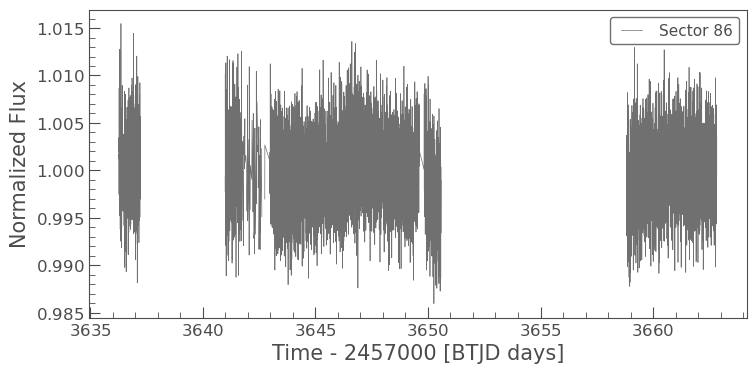

<Figure size 1000x600 with 0 Axes>

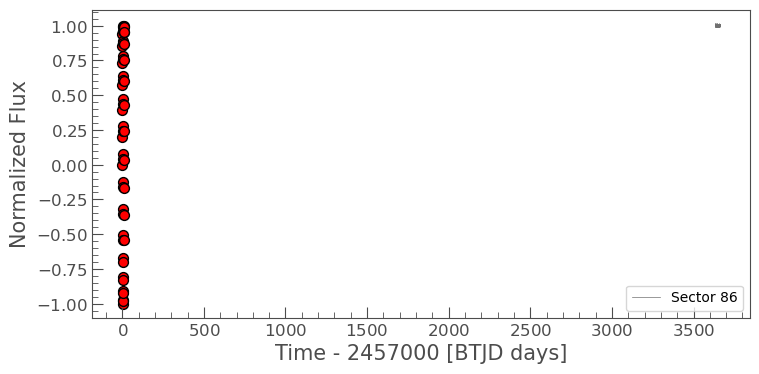

In [ ]:
# # Create a figure
# plt.figure(figsize=(10, 6))

# lc_collection = search_lightcurve("TIC 116986071", sector=86, mission="TESS").download_all();

# for lc in lc_collection:
#     (lc.normalize()).plot(label=f"Sector {lc.sector}", alpha=0.7)

# x = np.linspace(0, 10, 50)  # 50 points between 0 and 10
# y = np.sin(x)

# plt.scatter(x, y, s=50, c='red', marker='o', edgecolors='black')
# plt.legend()
# plt.show()

In [ ]:
# # Load a TESS FFI file
# tpf = lk.TessTargetPixelFile("/data/TIC_116986071__mag.tess");

# # Plot the Target Pixel File (TPF)
# tpf.plot()

NameError: name 'lk' is not defined

In [ ]:
search_results = lk.search_targetpixelfile("TIC 1551778142", sector=86, mission="TESS");
search_results

In [ ]:
pixelfile = lk.search_targetpixelfile("TIC 116986071", sector=86, mission="TESS").download();
pixelfile.animate()

In [ ]:
pixelfile = lk.search_targetpixelfile("TIC 116986071", sector=86, mission="TESS").download();
pixelfile.plot(aperture_mask="pipeline");

In [ ]:
pixelfile = lk.search_targetpixelfile("TIC 187531837", sector=86, mission="TESS").download();
pixelfile.to_lightcurve(method="pld").scatter();

In [ ]:
pixelfile = lk.search_targetpixelfile("TIC 187531837", sector=86, mission="TESS").download();
pixelfile.to_lightcurve(method="pld").remove_outliers().scatter();

In [ ]:
pixelfile = lk.search_targetpixelfile("TIC 187531837", sector=86, mission="TESS").download();
lc = pixelfile.to_lightcurve(method="pld").remove_outliers().flatten();
lc.to_periodogram("bls").plot()

In [ ]:
pixelfile = lk.search_targetpixelfile("TIC 187531837", sector=86, mission="TESS").download();
lc = pixelfile.to_lightcurve(method="pld").remove_outliers().flatten();
period = lc.to_periodogram("bls").period_at_max_power
lc.fold(period).scatter();

In [ ]:
pixelfile.to_lightcurve(method="pld").scatter();

In [ ]:
lc = pixelfile.to_lightcurve(method="pld").remove_outliers().flatten();
period = lc.to_periodogram("bls").period_at_max_power

In [ ]:
lc = lk.search_lightcurve(target=f"TIC 116986071", sector=86, mission="TESS").download();
lc.scatter();

In [ ]:
# Normalize flux by median value
median_flux = np.nanmedian(lc.flux)

# Convert flux to millimagnitudes
mmag = -2.5 * np.log10(lc.flux / median_flux) * 1000  # Convert to mmag

# Plot the light curve in millimagnitudes
plt.figure(figsize=(10, 5))
# Convert time to a numeric format
time_numeric = lc.time.value  # Extract time as float values
plt.plot(time_numeric, mmag, 'k.', markersize=2)
plt.xlabel("Time (days)")
plt.ylabel("Magnitude (mmag)")
plt.gca().invert_yaxis()  # Magnitudes decrease as brightness increases
plt.title("Light Curve for TIC 116986071 Sector 86")
plt.show()

In [ ]:
lc.show_properties()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Generate synthetic dataset (random stars)
np.random.seed(42)
temperature = np.random.uniform(3000, 30000, 500)  # Stellar temperatures (Kelvin)
luminosity = np.random.uniform(0.001, 1000, 500)  # Stellar luminosities (relative to Sun)

# Step 2: Define your specific star's data (Example: Sun)
my_star_temp = 5778  # Kelvin
my_star_lum = 1       # Solar Luminosity

# Step 3: Create H-R Diagram
plt.figure(figsize=(8, 6))
sc = plt.scatter(temperature, luminosity, c=np.log10(temperature), cmap='plasma', edgecolors='k', alpha=0.75)

# Reverse X-axis (Hot stars on the left, Cool stars on the right)
plt.gca().invert_xaxis()

# Step 4: Highlight your investigated star
plt.scatter(my_star_temp, my_star_lum, color='red', edgecolors='black', s=150, marker='*', label="Investigated Star")

# Step 5: Add Annotation
plt.text(my_star_temp, my_star_lum*1.5, " My Star", fontsize=12, color='black', ha='center', fontweight='bold')

# Labels and Title
plt.xlabel("Temperature (K)")
plt.ylabel("Luminosity (L☉)")
plt.title("Hertzsprung-Russell Diagram")

# Colorbar for temperature scale
cbar = plt.colorbar(sc, label="Log(Temperature)")

# Show Legend
plt.legend()

# Display the plot
plt.show()


*Lightkurve* has a class specifically for dealing with periodograms of time series data. This can be useful for finding the periods of variable stars. Below is a quick example of how to find the period of an [eclipsing binary star](https://en.wikipedia.org/wiki/Binary_star#Eclipsing_binaries).

First, let's grab a light curve file from the Kepler data archive. We'll use the object named KIC 10264202, which is an eclipsing binary observed by the original Kepler mission. We're just going to use one quarter of data for this demo.

In [ ]:
from lightkurve import search_lightcurve
lc = search_lightcurve('KIC 10264202', author="Kepler", quarter=10, cadence="long").download().remove_nans()

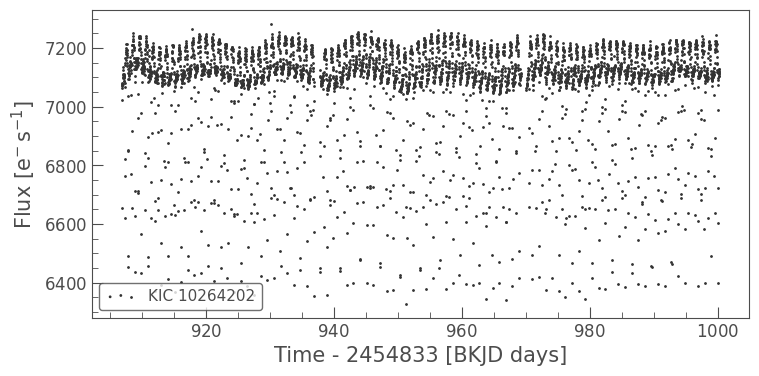

In [ ]:
%matplotlib inline
lc.scatter();

This light curve looks like it has some structure in it! Let's use the periodogram class to find the rotation period. You can create a periodogram from the `KeplerLightCurve` object by using the [to_periodogram](https://docs.lightkurve.org/reference/api/lightkurve.LightCurve.to_periodogram.html?highlight=to_periodogram) method.

In [ ]:
pg = lc.to_periodogram(oversample_factor=1)

Now we can plot the periodogram in the same way that we plot the original light curve.

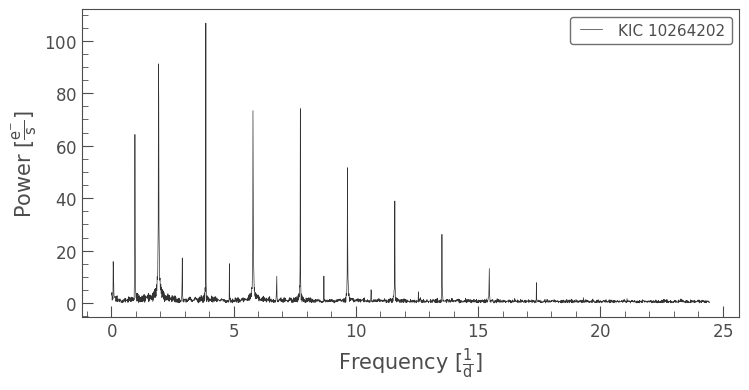

In [ ]:
pg.plot();

This looks like there is a huge signal at a certain frequency! Let's plot it in period space, so that we can see what period the oscillation is occurring at.

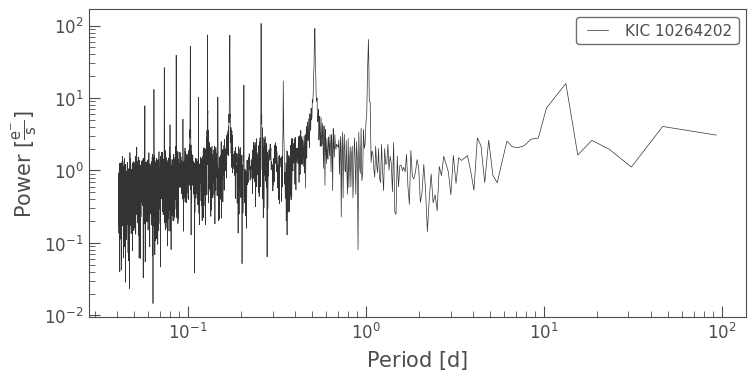

In [ ]:
pg.plot(view='period', scale='log');

This looks like a very fast period. We can access the full [period](https://docs.lightkurve.org/reference/api/lightkurve.periodogram.Periodogram.period.html?highlight=period#lightkurve.periodogram.Periodogram.period) and [power](https://docs.lightkurve.org/reference/api/lightkurve.periodogram.Periodogram.power.html?highlight=power#lightkurve.periodogram.Periodogram.power) data as follows:

In [ ]:
pg.period

<Quantity [9.34019490e+01, 4.67009745e+01, 3.11339830e+01, ...,
           4.09119356e-02, 4.08940232e-02, 4.08761265e-02] d>

In [ ]:
pg.power

<Quantity [3.08123446, 4.04910021, 1.11686323, ..., 0.38587616, 0.17210997,
           0.42668004] electron / s>

In this case we simply want to know the period that corresponds to the highest peak in the periodogram.  We can directly access this value using the convenient [period_at_max_power](https://docs.lightkurve.org/reference/api/lightkurve.periodogram.Periodogram.period_at_max_power.html?highlight=period_at_max_power) property:

In [ ]:
pg.period_at_max_power

<Quantity 0.25873116 d>

We can then use this period to fold our light curve:

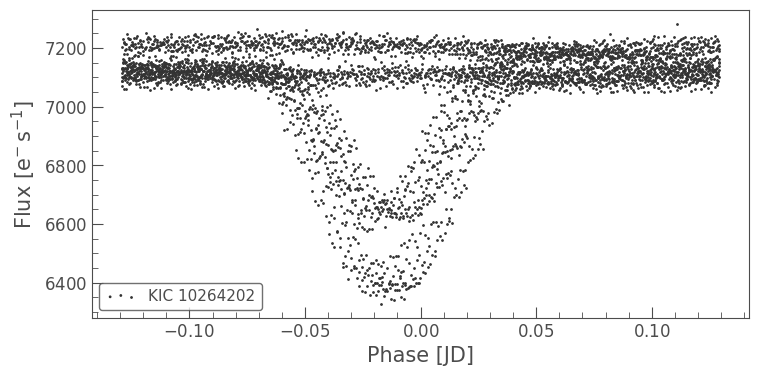

In [ ]:
lc.fold(period=pg.period_at_max_power).scatter();

Oops, the eclipses do not line up nicely. This does not look like the correct period of this eclipsing binary!

As is quite common for eclipsing binaries with deep secondary eclipses, we have found a harmonic of the period of the eclipsing binary. Let's plot it again with quadruple the period.

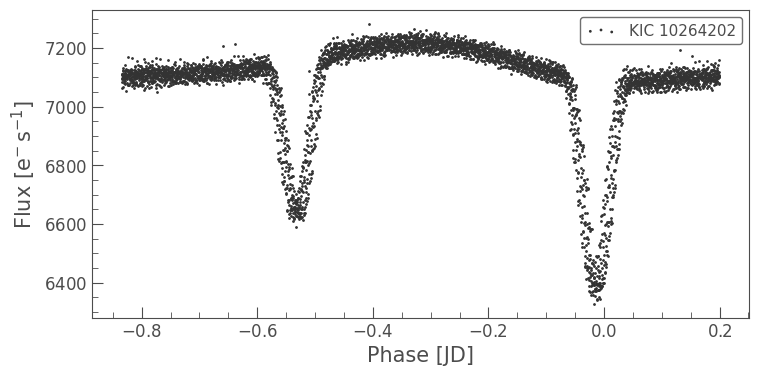

In [ ]:
lc.fold(period=4*pg.period_at_max_power, wrap_phase=0.2).scatter();

That looks better, but the eclipses still don't seem to line up as well as they could.

Let's try to get a more precise period by increasing the number of points in our periodogram using the `oversample_factor` parameter and by constraining the range of the period value:

In [ ]:
import astropy.units as u
pg = lc.to_periodogram(minimum_period=0.9*u.day, maximum_period=1.2*u.day, oversample_factor=10)
pg.period_at_max_power

<Quantity 1.03509717 d>

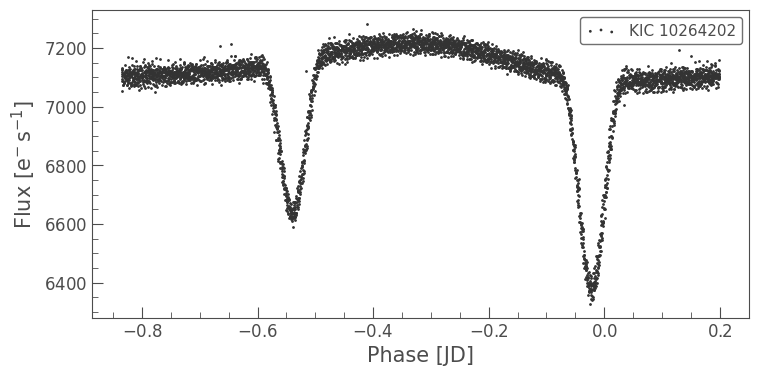

In [ ]:
lc.fold(period=pg.period_at_max_power, wrap_phase=0.2).scatter();

This has improved our fit. It looks like this eclipsing binary has a period of approximately 1 day.

## Seismology


In [ ]:
import lightkurve as lk
lc = lk.search_lightcurve("HIP 116158", sector=2).download()
lc = lc.normalize().remove_nans().remove_outliers()

/usr/local/lib/python3.11/dist-packages/lightkurve/search.py:424: LightkurveWarning: Warning: 8 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


In [ ]:
pg = lc.to_periodogram(normalization='psd', minimum_frequency=100, maximum_frequency=800)

In [ ]:
seismology = pg.flatten().to_seismology()

In [ ]:
numax = seismology.estimate_numax()
numax

numax: 405.00 uHz (method: ACF2D)

array([<Axes: ylabel='Signal to Noise Ratio (SNR)'>,
       <Axes: ylabel='Frequency lag [$\\mathrm{\\mu Hz}$]'>,
       <Axes: xlabel='Frequency [$\\mathrm{\\mu Hz}$]', ylabel='Correlation Metric'>],
      dtype=object)

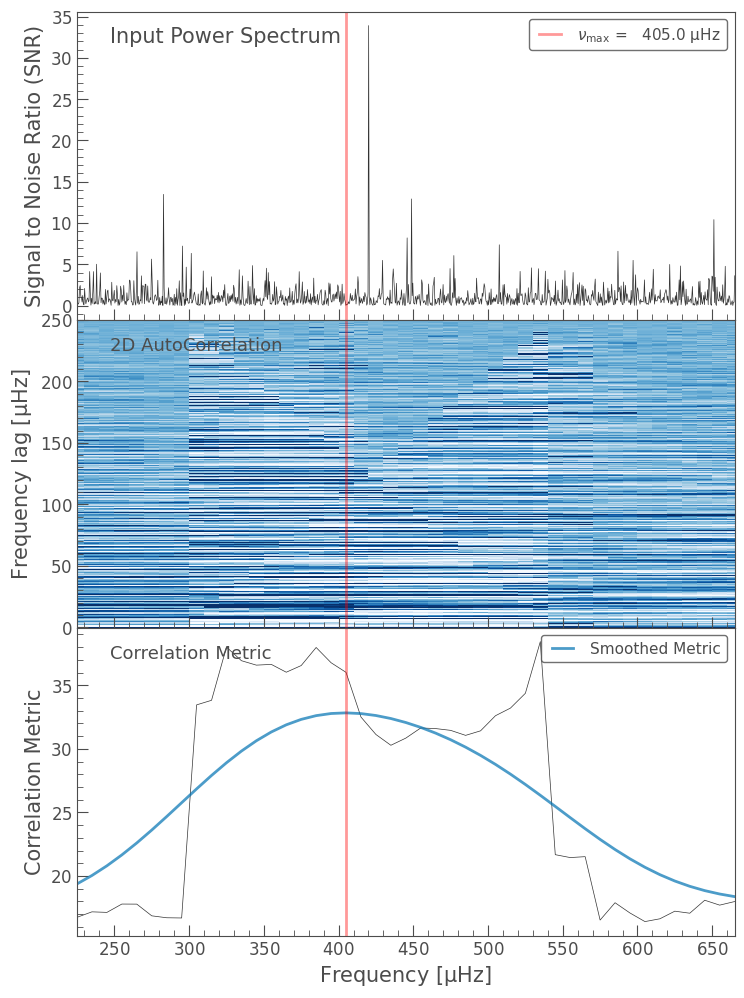

In [ ]:
seismology.diagnose_deltanu(seismology.estimate_numax()  )

In [ ]:
deltanu = seismology.estimate_deltanu()
deltanu

deltanu: 28.78 uHz (method: ACF2D)

<Axes: xlabel='Frequency Lag [$\\mathrm{\\mu Hz}$]', ylabel='Scaled Auto Correlation'>

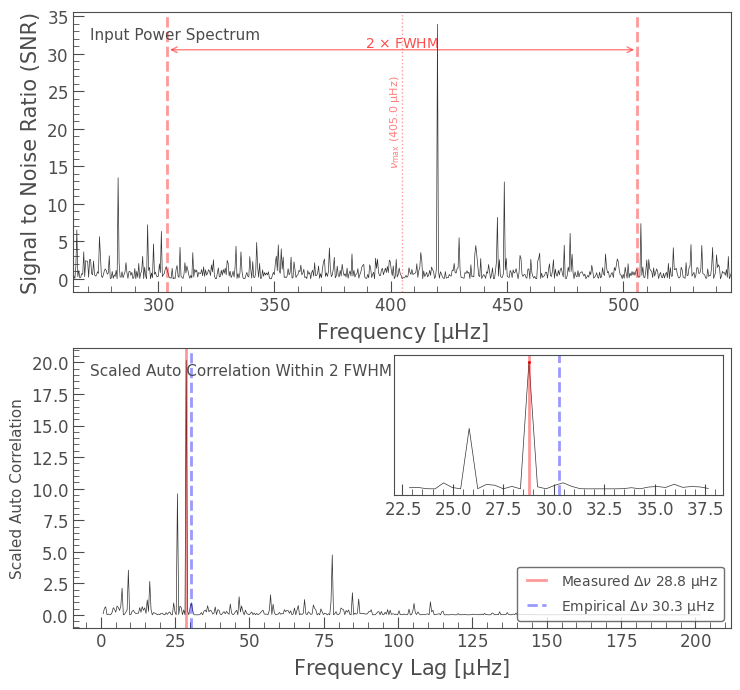

In [ ]:
seismology.diagnose_deltanu(seismology.estimate_deltanu()  )

In [ ]:
seismology.estimate_radius(teff=5080)

radius: 2.71 solRad (method: Uncorrected Scaling Relations)

In [ ]:
seismology.estimate_mass(teff=5080, numax=numax, deltanu=deltanu)

mass: 0.90 solMass (method: Uncorrected Scaling Relations)

<Axes: title={'center': 'Echelle diagram for TIC 441462736'}, xlabel='Frequency mod. 28.78 uHz', ylabel='Frequency [$\\mathrm{\\mu Hz}$]'>

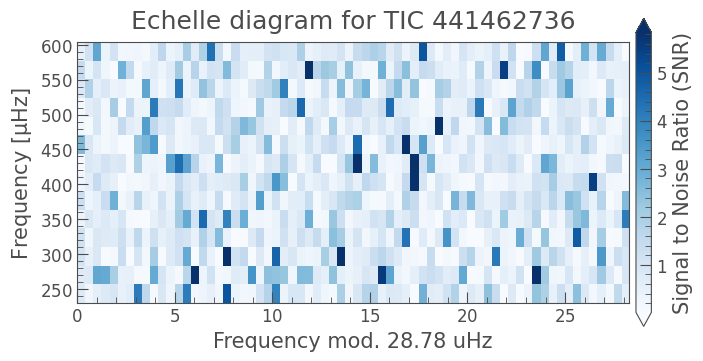

In [ ]:
seismology.plot_echelle(numax=numax, deltanu=deltanu)

In [ ]:
# seismology.interact_echelle("notebook_url")

## Inteructions
